# Lab 4: Six Weeks Later
**ADSA 8035, Week 4** | Part 1 of the Injury Risk Technical Report | About 2.5 hours | Due **Thursday, September 24, 11:59 PM ET**

---

> **From:** Dr. Ellen Marsh, Head of Medical
> **To:** you
> **Cc:** Dana Whitmore
> **Sent:** Monday, 07:40
>
> The protocol block has finished. Before I renew it I need to know one thing.
>
> Your four names. How many were right?
>
> And I do not mean "the model was well calibrated." I mean: of the players you told me to worry about, how many actually went down long, and how many did I spend a bed on for nothing. And the players who went down long that were nowhere near your list, how many of those were there?
>
> Then tell me whether I should keep using this, and if I do, where I should draw the line. Last time you gave me the base rate. I want a line I can defend to the manager in money.
>
> Thursday for the numbers. Sunday for the report.

---

Three weeks ago you built the list. This week you find out how good it was.

**How this lab fits the week.** In the build video you counted every metric by hand. In the deep dive you built the tools and discovered what they reveal. **This lab is where you use them to answer Ellen**, and it produces every number and figure the report needs. You may use scikit-learn's functions directly now; you have earned it. If you did the deep dive, you can reuse your functions from it.

This notebook is **Part 1** of the Technical Report. Part 2, due Sunday, is the written report itself; the brief is on the Canvas assignment page. The last section of this lab is a draft of the report's opening paragraph, so by Thursday you will have started it.

**Seven parts, about two and a half hours.** Six check cells tell you whether each piece is right.

**One thing to know going in.** You are about to discover that this model is, by some measures, worse than doing nothing. That is not a bug and it is not your fault. It is the most important finding in the lab, and saying it clearly is what earns the marks.

## Setup (provided)

Everyone evaluates **the same model**: the Lab 3 build, rebuilt here exactly, same features, same split, same seed. That way your evaluation is not affected by any bug in your own Lab 3, and every number in the class is comparable.

Run it. The fingerprint at the bottom should read the same for everyone.

In [1]:
import pandas as pd
import numpy as np
import hashlib

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                             recall_score, roc_curve, roc_auc_score, brier_score_loss)

import warnings
warnings.filterwarnings('ignore')

# Set global font size for figures
plt.rcParams.update({'font.size': 12})


def parse_injury_date(value):
    if pd.isna(value):
        return pd.NaT
    text = str(value).strip()
    if text.lower() == "present":
        return pd.NaT
    text = text.replace(",", ", ").replace("  ", " ")
    for fmt in ("%b %d, %Y", "%B %d, %Y"):
        try:
            return pd.to_datetime(text, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT


FIRST_INJURY_FILL = 365
MUSCLE_WORDS = "hamstring|calf|groin|muscle|thigh|strain|quad|adductor"
JOINT_WORDS = "knee|ankle|ligament|cruciate|meniscus|shoulder|hip|foot|toe"
BONE_WORDS = "fracture|broken|metatarsal|collarbone|rib"
HEAD_ILL_WORDS = "concussion|head|illness|virus|corona|covid|ill"


def build_features(df):
    """Feature layer v2.0, identical to Labs 2 and 3."""
    out = df.copy()
    out["injury_date"] = out["Date of Injury"].apply(parse_injury_date)
    out["return_date"] = out["Date of return"].apply(parse_injury_date)
    out["days_out"] = (out["return_date"] - out["injury_date"]).dt.days
    out["date_error"] = (out["days_out"] < 0) | (out["days_out"] > 1000)
    out.loc[out["date_error"], "days_out"] = np.nan
    out = out.sort_values(["Name", "injury_date", "Injury"]).copy()
    out["prior_injuries"] = out.groupby("Name").cumcount()
    gap = out.groupby("Name")["injury_date"].diff().dt.days
    out["first_injury"] = gap.isna().astype(int)
    out["days_since_last"] = gap.fillna(FIRST_INJURY_FILL).clip(upper=FIRST_INJURY_FILL)
    text = out["Injury"].str.lower().fillna("")
    out["body_region"] = np.select(
        [text.str.contains(MUSCLE_WORDS), text.str.contains(JOINT_WORDS),
         text.str.contains(BONE_WORDS), text.str.contains(HEAD_ILL_WORDS)],
        ["muscle", "joint", "bone", "head_or_illness"], default="other")
    before_cols = [c for c in out.columns if "before_injury_Result" in c]
    points = {"win": 3, "draw": 1, "lose": 0}
    out["form_before"] = (out[before_cols].replace(points)
                          .apply(pd.to_numeric, errors="coerce").mean(axis=1))
    prev_region = out.groupby("Name")["body_region"].shift(1)
    out["recurrence"] = (out["body_region"] == prev_region).astype(int)
    out["long_absence"] = (out["days_out"] > 30).astype(int)
    return out


injury_df = pd.read_csv("https://drive.google.com/uc?export=download&id=1Uaftofu7Ygip2-LOmdyGqQGjK_Ci6QWh", na_values=["N.A."])
features_df = build_features(injury_df)
model_df = features_df.dropna(subset=["days_out", "form_before"]).copy()

NUMERIC = ["Age", "FIFA rating", "prior_injuries", "days_since_last", "form_before", "recurrence", "first_injury"]
CATEGORICAL = ["Position", "body_region"]

x_train, x_test, y_train, y_test = train_test_split(
    model_df[NUMERIC + CATEGORICAL], model_df["long_absence"],
    test_size=0.25, random_state=42, stratify=model_df["long_absence"])

model = Pipeline([
    ("pre", ColumnTransformer([("scaler", StandardScaler(), NUMERIC),
                               ("one_hot", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)])),
    ("model", LogisticRegression(max_iter=1000)),
]).fit(x_train, y_train)

test_probs = model.predict_proba(x_test)[:, 1]
train_probs = model.predict_proba(x_train)[:, 1]
test_frame = model_df.loc[x_test.index, ["Name", "Injury", "days_out", "long_absence"]].copy()
test_frame["prob"] = test_probs.round(3)

fingerprint = hashlib.md5(np.round(model.named_steps["model"].coef_[0], 6).tobytes()).hexdigest()[:12]
print("Model rebuilt. Training rows: " + str(len(x_train)) + "   Test rows: " + str(len(x_test)))
print("Test-set base rate (share of long absences): " + str(round(y_test.mean(), 3)))
print("Fingerprint: " + fingerprint + "   <- should match every classmate's")

Model rebuilt. Training rows: 454   Test rows: 152
Test-set base rate (share of long absences): 0.408
Fingerprint: 2a64cda4fac2   <- should match every classmate's


**The four boxes, one more time, for reference.** Every metric in this lab divides these four counts.

| | **He ran long** | **He came back quickly** |
|---|---|---|
| **On the list** | **True positive (TP):** flagged, and right | **False positive (FP):** a false alarm, a wasted bed |
| **Not on the list** | **False negative (FN):** a miss, nobody saw it coming | **True negative (TN):** correctly left alone |

---

## Part 1: The Grade That Lies (10 min)

Ellen's first instinct will be to ask "how accurate is it?" You need to be able to tell her, with two numbers, why that is the wrong question.

Compute `model_accuracy` at the default 0.5 cutoff, and `always_fine_accuracy` for a model that predicts every injury comes back quickly.

In [2]:
# TODO: model_accuracy at 0.5; always_fine_accuracy for a model that predicts 0 for everyone

model_accuracy = accuracy_score(y_test, test_probs >= 0.5)
always_fine_accuracy = accuracy_score(y_test, [0] * len(y_test))

print(model_accuracy, always_fine_accuracy)

0.5723684210526315 0.5921052631578947


In [3]:
# CHECK 1
if "model_accuracy" in dir() and "always_fine_accuracy" in dir():
    assert abs(model_accuracy - accuracy_score(y_test, (test_probs >= 0.5).astype(int))) < 1e-9, "model_accuracy should use a 0.5 cutoff on test_probs."
    assert abs(always_fine_accuracy - (1 - y_test.mean())) < 1e-9, "The Always Fine model predicts 0 for everyone, so its accuracy is the share of short absences."
    print("Check 1 passes.")
else:
    print("Part 1 not built yet.")

Check 1 passes.


**For the report (2 sentences):** which is more accurate, and why does that say almost nothing about whether the model is useful to Ellen?

The always fine model, which predicts every player comes back quickly, is more accurate than ours (59.2% vs 57.2%). Thats becuase about 41% of injuries run long, so you can score well just by guessing the common outcome, while catching zero of the long absences Ellen actually cares about.



## Part 2: The Report Table (20 min)

The report needs one confusion matrix, at the cutoff you would actually use, labeled so a physio can read it. Use the **training base rate** as the cutoff for now: `REPORT_CUTOFF = round(y_train.mean(), 2)`. Part 5 revisits it with your costs.

1. Build `report_cm`: a DataFrame with rows `on list` / `not on list` and columns `ran long` / `back quickly`. Note that `confusion_matrix` returns `[[TN, FP], [FN, TP]]`, a different layout; rearrange it.
2. Compute `report_precision` and `report_recall` at the same cutoff.

In [4]:
# TODO: REPORT_CUTOFF, report_cm (labeled), report_precision, report_recall

REPORT_CUTOFF = round(y_train.mean(), 2)
preds = test_probs >= REPORT_CUTOFF

tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

report_cm = pd.DataFrame([[tp, fp], [fn, tn]],
                         index=["on list", "not on list"],
                         columns=["ran long", "back quickly"])

report_precision = precision_score(y_test, preds)
report_recall = recall_score(y_test, preds)

print(REPORT_CUTOFF)
print(report_cm)
print(report_precision, report_recall)

0.41
             ran long  back quickly
on list            32            39
not on list        30            51
0.4507042253521127 0.5161290322580645


In [5]:
# CHECK 2
if "report_cm" in dir() and "report_precision" in dir():
    assert list(report_cm.columns) == ["ran long", "back quickly"] and list(report_cm.index) == ["on list", "not on list"], "Label the rows and columns exactly as asked."
    assert report_cm.values.sum() == len(y_test), "The four cells must add up to the test set."
    assert report_cm["ran long"].sum() == y_test.sum(), "The 'ran long' column must add up to the actual long absences. Is the layout rearranged?"
    assert abs(report_precision - report_cm.loc["on list", "ran long"] / report_cm.loc["on list"].sum()) < 1e-9, "Precision should equal TP / (TP + FP) from your table."
    assert abs(report_recall - report_cm.loc["on list", "ran long"] / report_cm["ran long"].sum()) < 1e-9, "Recall should equal TP / (TP + FN) from your table."
    print("Check 2 passes.")
else:
    print("Part 2 not built yet.")

Check 2 passes.


**For the report (3 sentences):**
1. Read the table to Ellen: how many long absences did the list miss, and how many beds went to players who were back quickly?
2. One sentence to the physio about precision, one to the manager about recall.
3. Precision against the base rate: what does the gap mean for a name on the list?

A) Out of 71 players on the list, 32 actually ran long, so 39 beds went to guys who were back quickly, and we still missed 30 long absences that werent on the list at all.

B) For the physio: when a name is on the list, its a long absence about 45% of the time, so less than a coin flip. For manager the list only caught about half (52%) of the long absences.

C) The list hits at 45% and a random pick hits at 41%, so being on the list barely moves the needle. A name on it is only a little more worrying than any random injury.

## Part 3: How Well Does It Rank, and How Sure Are You? (25 min)

Two things the report needs here: a **report-quality ROC figure**, and an **honest range** for the AUC.

1. Plot, on one figure: the test ROC curve (solid), the training ROC curve (dashed), the diagonal, and your report cutoff marked as a point on the test curve. Include both AUCs in the legend. Title the figure with the finding, not the variable name.
2. Store `auc_test` and `auc_train`.
3. Bootstrap the test set 1,000 times with `rng = np.random.default_rng(1)`: each time draw `len(y_test)` positions **with replacement**, compute the AUC on those positions, and skip any sample with only one class. Store the 5th and 95th percentiles as `auc_low` and `auc_high`.

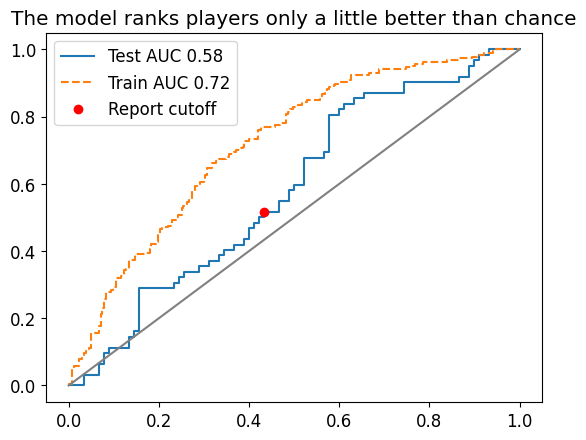

0.5815412186379929 0.7189008391916523 0.5076292892156862 0.6541888273382885


In [6]:
# TODO: the ROC figure (test, train, diagonal, your cutoff); auc_test, auc_train; auc_low, auc_high from 1,000 bootstrap samples

auc_test = roc_auc_score(y_test, test_probs)
auc_train = roc_auc_score(y_train, train_probs)

fpr, tpr, _ = roc_curve(y_test, test_probs)
fpr2, tpr2, _ = roc_curve(y_train, train_probs)

plt.plot(fpr, tpr, label=f"Test AUC {auc_test:.2f}")
plt.plot(fpr2, tpr2, "--", label=f"Train AUC {auc_train:.2f}")
plt.plot([0, 1], [0, 1], "gray")
plt.plot(fp / (fp + tn), report_recall, "ro", label="Report cutoff")
plt.title("The model ranks players only a little better than chance")
plt.legend()
plt.show()

rng = np.random.default_rng(1)
y = y_test.values
aucs = []
for i in range(1000):
    idx = rng.integers(0, len(y), len(y))
    if y[idx].min() != y[idx].max():
        aucs.append(roc_auc_score(y[idx], test_probs[idx]))

auc_low, auc_high = np.percentile(aucs, [5, 95])
print(auc_test, auc_train, auc_low, auc_high)

In [7]:
# CHECK 3
if "auc_test" in dir() and "auc_low" in dir() and "auc_high" in dir():
    assert abs(auc_test - roc_auc_score(y_test, test_probs)) < 1e-9, "auc_test must be computed on the test set."
    assert abs(auc_train - roc_auc_score(y_train, train_probs)) < 1e-9, "auc_train must be computed on the training set."
    assert auc_low < auc_test < auc_high, "The test AUC should sit inside its own bootstrap interval."
    assert 0.3 < auc_low < 0.6 and 0.55 < auc_high < 0.8, "The interval looks off. Resample positions with replacement, and use probabilities, not labels."
    print("Check 3 passes. AUC " + str(round(auc_test, 3)) + ", 90 percent interval " + str(round(auc_low, 3)) + " to " + str(round(auc_high, 3)) + ".")
else:
    print("Part 3 not built yet.")

Check 3 passes. AUC 0.582, 90 percent interval 0.508 to 0.654.


**For the report (3 sentences):**
1. AUC in plain language, with your number: "if you pick one player who ran long and one who did not..."
2. The honest range: "AUC 0.58, plausibly anywhere from ... to ...". What does the lower end of that range mean?
3. The training-versus-test gap, and what it tells Ellen about how much to trust the model on new players.

A) If you pick one player who ran long and one who came back quickly, the model gives the long one a higher risk score about 58% of the time. A coin flip gets 50%Z.

B) Honestly, the AUC is 0.58, but it could plausibly be anywhere be from 0.51 to 0.65. The low end is basically a coin flip, so we cant rule out that the model barely ranks batter than random.

C) It scores 0.72 on the players it trained on but only 0.58 on new ones, so it learned some noise from the training data. Ellen should expect the weaker number number on new players.

## Part 4: Should Ellen Believe the Numbers? (20 min)

AUC only measures **order**. It cannot tell you whether a probability of 0.6 means 60 percent. Ellen asked exactly that in Week 3, so the report has to answer it.

1. Build `calib`: split the test set into five equal groups with `pd.qcut(test_probs, 5, labels=False)`, and for each group record `mean_predicted`, `share_long`, and `n`.
2. Plot it against the diagonal, with the counts labeled on each point.
3. Compute `brier_model`, the Brier score of the model: the average of (probability minus outcome) squared. And `brier_baseline`: the Brier score of saying `y_train.mean()` for every test player. Lower is better.

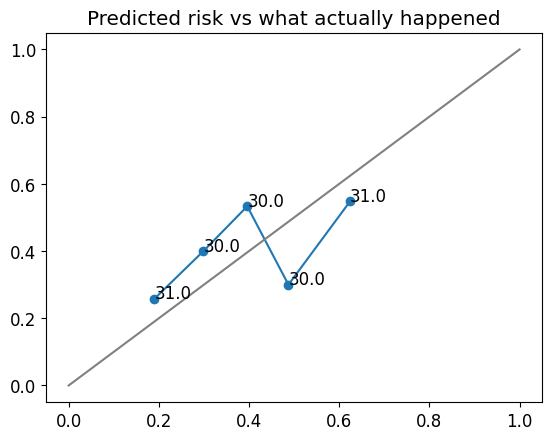

       mean_predicted  share_long   n
group                                
0            0.190241    0.258065  31
1            0.298976    0.400000  30
2            0.396113    0.533333  30
3            0.487451    0.300000  30
4            0.624352    0.548387  31
0.24703593202791063 0.2415326167891152


In [8]:
# TODO: calib (5 groups), a calibration figure, brier_model and brier_baseline

calib = pd.DataFrame({"prob": test_probs, "long": y_test.values})
calib["group"] = pd.qcut(test_probs, 5, labels=False)
calib = calib.groupby("group").agg(mean_predicted=("prob", "mean"),
                                   share_long=("long", "mean"),
                                   n=("long", "size"))

plt.plot(calib["mean_predicted"], calib["share_long"], "o-")
plt.plot([0, 1], [0, 1], "gray")
for i, row in calib.iterrows():
    plt.text(row["mean_predicted"], row["share_long"], row["n"])
plt.title("Predicted risk vs what actually happened")
plt.show()

brier_model = np.mean((test_probs - y_test.values) ** 2)
brier_baseline = np.mean((y_train.mean() - y_test.values) ** 2)

print(calib)
print(brier_model, brier_baseline)

In [9]:
# CHECK 4
if "calib" in dir() and "brier_model" in dir() and "brier_baseline" in dir():
    assert len(calib) == 5 and calib["n"].sum() == len(y_test), "calib needs five groups covering the whole test set."
    assert abs(brier_model - brier_score_loss(y_test, test_probs)) < 1e-9, "brier_model should match brier_score_loss."
    assert abs(brier_baseline - brier_score_loss(y_test, np.full(len(y_test), y_train.mean()))) < 1e-9, "brier_baseline predicts the TRAINING base rate for every test player."
    print("Check 4 passes. Model " + str(round(brier_model, 4)) + ", say-the-base-rate " + str(round(brier_baseline, 4)) + ".")
else:
    print("Part 4 not built yet.")

Check 4 passes. Model 0.247, say-the-base-rate 0.2415.


**For the report (3 sentences):** does the model's top group run long about as often as it predicts? Which Brier score is lower, and what does that mean in plain words? And what should Ellen do with the probabilities: read them as percentages, or only as a ranking?

The top group is overconfident: the model says about 62% but only 55% actually ran long, and the groups dont even climb steadily (the 49% only hit 30%). The Brier score is actually a bit worse for the model (0.247) than for just saying 41% for every player (0.242), so its probabilities are less accurate than doing nothing. Ellen shouldnt read the numbers as real percentages. At most, use them as a rough ranking of who to look at first.

## Part 5: Your Line, and Her Four Beds (30 min)

Two halves. First, the line your costs choose. Then, the question that matters more when capacity is fixed: is the top of the list any better than picking at random?

**5a. Your cost ratio.** Put in the ratio you argued in last week's discussion. If you did not post one, use 30 and say so in the report.

In [10]:

# YOUR NUMBERS, from your Week 3 discussion post.
MISS_COST = 8       # missed long absence: ~0.5 wins-equivalent (2-3 games lost + scholarship with no return)
ALARM_COST = 1      # false alarm: ~0.06 wins-equivalent (a week of modified training)
print("Your cost ratio: " + str(MISS_COST / ALARM_COST) + " to 1")

Your cost ratio: 8.0 to 1


In [11]:
# Rerun 5a with a ratio of 2 to 1
y = y_test.values
cutoffs = np.arange(0.05, 0.91, 0.01).round(2)
costs2 = []
for c in cutoffs:
    misses = ((test_probs < c) & (y == 1)).sum()
    alarms = ((test_probs >= c) & (y == 0)).sum()
    costs2.append(misses * 2 + alarms * 1)

best_cutoff_2 = cutoffs[np.argmin(costs2)]
flagged_2 = int((test_probs >= best_cutoff_2).sum())
print(best_cutoff_2, flagged_2)

0.29 107


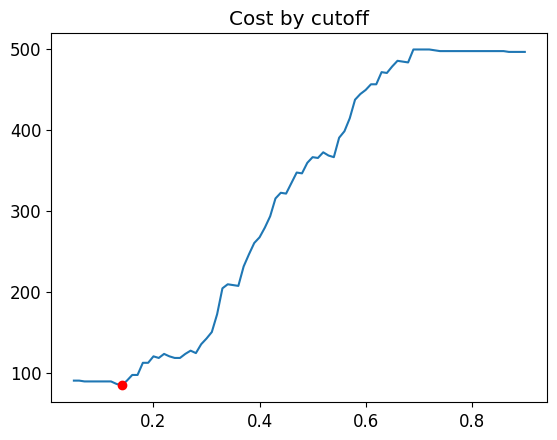

0.14 146


In [12]:
y = y_test.values
cutoffs = np.arange(0.05, 0.91, 0.01).round(2)
costs = []
for c in cutoffs:
    misses = ((test_probs < c) & (y == 1)).sum()
    alarms = ((test_probs >= c) & (y == 0)).sum()
    costs.append(misses * MISS_COST + alarms * ALARM_COST)

best_cutoff = cutoffs[np.argmin(costs)]
flagged_at_best = int((test_probs >= best_cutoff).sum())

plt.plot(cutoffs, costs)
plt.plot(best_cutoff, min(costs), "ro")
plt.title("Cost by cutoff")
plt.show()
print(best_cutoff, flagged_at_best)

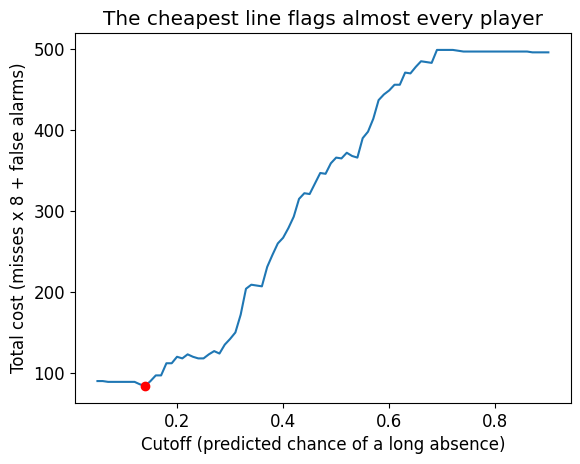

In [18]:
plt.plot(cutoffs, costs)
plt.plot(best_cutoff, min(costs), "ro")
plt.xlabel("Cutoff (predicted chance of a long absence)")
plt.ylabel("Total cost (misses x 8 + false alarms)")
plt.title("The cheapest line flags almost every player")
plt.savefig("figure2_cost.png", dpi=200, bbox_inches="tight")
plt.show()

For every cutoff from 0.05 to 0.90 in steps of 0.01, compute the cost on the test set: misses times `MISS_COST` plus false alarms times `ALARM_COST`. Store the cheapest as `best_cutoff` and how many players it flags as `flagged_at_best`. Plot cost against cutoff with the cheapest point marked.

**5b. The four beds.** With four beds, the cutoff does not matter; Ellen takes the top four names. So:

1. Print the top four from `test_frame`, with probability, days out, and whether they ran long.
2. Compute `prec_at_k`, the share of the top k that ran long, for every k from 1 to the test size.
3. Shuffle `y_test` 2,000 times with `np.random.default_rng(0).permutation`, computing the same cumulative precision each time, and store the 5th and 95th percentiles at each k as `random_low` and `random_high`.
4. Print the model against the random band at k = 4, 10 and 20.

In [13]:
# TODO: 5a best_cutoff, flagged_at_best, cost plot; 5b top four, prec_at_k, random_low, random_high, comparison at k = 4, 10, 20

y = y_test.values
order = np.argsort(-test_probs)

# Top four
print(test_frame.iloc[order[:4]])

# Precision at k
k = np.arange(1, len(y) + 1)
prec_at_k = np.cumsum(y[order]) / k

# Random band
rng = np.random.default_rng(0)
sims = [np.cumsum(rng.permutation(y)) / k for i in range(2000)]
random_low, random_high = np.percentile(sims, [5, 95], axis=0)

# Model vs random at k = 4, 10, 20
for n in [4, 10, 20]:
    print(n, prec_at_k[n - 1], random_low[n - 1], random_high[n - 1])

                 Name                 Injury  days_out  long_absence   prob
416      Oliver Skipp             Hip injury      25.0             0  0.867
476  Giovani Lo Celso            Knee injury       5.0             0  0.733
65        Joe Willock            Knee injury      24.0             0  0.730
497    Matthew Lowton  ankle and knee injury     119.0             1  0.687
4 0.25 0.0 0.75
10 0.4 0.2 0.7
20 0.4 0.25 0.6


In [14]:
# CHECK 5
if "best_cutoff" in dir() and "prec_at_k" in dir() and "random_low" in dir():
    assert 0.05 <= best_cutoff <= 0.90, "best_cutoff should come from your grid."
    assert flagged_at_best == int((test_probs >= best_cutoff).sum()), "flagged_at_best should count players at or above best_cutoff."
    assert abs(prec_at_k[-1] - y_test.mean()) < 1e-9, "With every name on the list, precision at k equals the base rate."
    assert abs(prec_at_k[3] - y_test.values[np.argsort(-test_probs)][:4].mean()) < 1e-9, "prec_at_k[3] is the top four, ranked highest first."
    assert (random_low <= random_high).all(), "random_low should never exceed random_high."
    print("Check 5 passes. Your line flags " + str(flagged_at_best) + "; the top four hit " + str(round(prec_at_k[3], 2)) + ".")
else:
    print("Part 5 not built yet.")

Check 5 passes. Your line flags 146; the top four hit 0.25.


**For the report (4 to 5 sentences):** your ratio and who pays each cost; how many players the cheapest line flags, and why that is the same as having no model when she has four beds; how many of the top four ran long; and whether the list beats picking names at random. Rerun 5a with a ratio of 2 before you write, and say what changed.

My ratio is 8 to 1 from my week 3 post, missing a long absence costs about 0.5 wins, equivalent (2-3 games lost plus a scholarship player giving you nothing back) while a false alarm costs about 0.06 (a week of modified training). The team and the manager pay fro the misses, the medical staff and the player pay for the false alarms. At 8 to 1 the cheapest line is a cutoff of 0.14, which flags 146 of 152 players. Thats basically everyone, and with only four beds, a list of basically everyone tells Ellen nothing, same as having no model. Of the top four, only 1 actually ran long (Lowton, 119 days) and at the top 4,10, and 20 the model lands inside the random band every time (25%, 40%, 40%) so there no evidence that list beats pulling names out of a hat. Dropping the ratio to 2 moves the line to 0.29 and flags 107 players, but still dosent fix the real problem, the ranking is barely better than chance.

## Part 6: One Refinement, Judged Honestly (25 min)

This is the one new skill in the lab. The syllabus asks you to refine the model from its evaluation. The trap is that almost any change moves the test AUC a little, and with 152 test players a little is meaningless. So you will measure the change **and its uncertainty.**

1. Make **one** change and refit. Options: drop the feature whose Lab 3 odds multiplier was closest to 1.0; add your Lab 2 feature; refit with `class_weight="balanced"`; or something you can defend in one sentence. Store its test probabilities as `refined_probs`.
2. Compute `auc_change`, the refined AUC minus `auc_test`.
3. **Paired bootstrap.** 1,000 times with `rng = np.random.default_rng(3)`: draw one set of test positions with replacement, and compute the AUC of **both** models on **those same positions**, then take the difference. Using the same positions for both is what makes it paired: it removes the luck of the draw that the two models share. Store the 5th and 95th percentiles as `change_low` and `change_high`.
4. If that interval contains zero, the honest verdict is: no evidence the change helped.

In [15]:
# TODO: one refinement -> refined_probs; auc_change; change_low and change_high from a paired bootstrap

from sklearn.base import clone

# Refinement: same model, but balanced class weights
refined = clone(model).set_params(model__class_weight="balanced")
refined.fit(x_train, y_train)
refined_probs = refined.predict_proba(x_test)[:, 1]

auc_change = roc_auc_score(y_test, refined_probs) - auc_test

# Paired bootstrap: same positions for both models
rng = np.random.default_rng(3)
y = y_test.values
diffs = []
for i in range(1000):
    idx = rng.integers(0, len(y), len(y))
    if y[idx].min() != y[idx].max():
        diffs.append(roc_auc_score(y[idx], refined_probs[idx]) - roc_auc_score(y[idx], test_probs[idx]))

change_low, change_high = np.percentile(diffs, [5, 95])
print(auc_change, change_low, change_high)

-0.0008960573476703981 -0.0038636843144061574 0.0020956129963771385


In [16]:
# CHECK 6
if "refined_probs" in dir() and "auc_change" in dir() and "change_low" in dir():
    assert len(refined_probs) == len(y_test), "refined_probs needs one probability per test injury."
    assert abs(auc_change - (roc_auc_score(y_test, refined_probs) - auc_test)) < 1e-9, "auc_change is the refined test AUC minus auc_test."
    assert change_low <= change_high, "change_low should not exceed change_high."
    assert change_low - 0.1 < auc_change < change_high + 0.1, "The observed change should sit near its own interval. Did you use the same positions for both models?"
    print("Check 6 passes. Change " + str(round(auc_change, 3)) + ", interval " + str(round(change_low, 3)) + " to " + str(round(change_high, 3)) + ".")
else:
    print("Part 6 not built yet.")

Check 6 passes. Change -0.001, interval -0.004 to 0.002.


In [17]:
names = model.named_steps["pre"].get_feature_names_out()
odds = np.exp(model.named_steps["model"].coef_[0])
print(pd.Series(odds, index=names).sort_values().round(2))

one_hot__body_region_head_or_illness       0.30
one_hot__Position_Left Midfielder          0.36
one_hot__Position_Defensive Midfielder     0.65
one_hot__body_region_other                 0.66
one_hot__Position_Center Forward           0.69
scaler__FIFA rating                        0.74
one_hot__Position_Left Back                0.84
one_hot__Position_Attacking Midfielder     0.85
scaler__days_since_last                    0.88
one_hot__Position_Right winger             0.93
scaler__Age                                0.94
one_hot__Position_Left winger              0.96
one_hot__Position_Central Midfielder       1.07
scaler__form_before                        1.09
one_hot__Position_Center Back              1.13
scaler__recurrence                         1.15
one_hot__Position_Goalkeeper               1.17
one_hot__body_region_muscle                1.28
one_hot__Position_Central Midfielder       1.28
scaler__prior_injuries                     1.34
scaler__first_injury                    

**For the report (2 to 3 sentences):** what you changed and why, the

*   List item
*   List item

change in AUC with its interval, and your verdict. "The AUC rose 0.01, but the interval runs from minus 0.03 to plus 0.05, so there is no evidence the change helped" is a strong sentence. "The refined model is better" is not, unless your interval excludes zero.

I refit the model with class_weight="balanced", since long absences are the rarer outcome and I wanted the model to take them more seriously. The AUC actually dropped by 0.001 and the internal runs from -0.004 to +0.002 so it crosses zero. Theres no evidence the change, helped, which makes sense: balancing mostly pushes every players probability up without changing, who ranks above who, and AUC only cares about the order.

## Part 7: Start the Report (15 min)

**Carry forward.** Fill in your numbers. This table is all you need open on Sunday.

| Quantity | Your value |
|---|---|
| Test base rate | 0.408 (62 of 152)|
| Model accuracy at 0.5 / Always Fine accuracy | 0.572 / 0.592 |
| At the report cutoff: caught, false alarms, missed, left alone | 32, 39, 30, 51 |
| Precision / recall at the report cutoff |0.451, 0.516 |
| Test AUC, its 90 percent interval, and the training AUC |0.582 (0.508 to 0.654: train 0.719 |
| Top group: predicted vs actual; Brier model vs baseline |0.62 predicted vs 0.55 actual: 0.2470 vs 0.2415 |
| Your cost ratio, cheapest cutoff, players it flags | 8 to 1 (week 3): 0.14: 146 of 152 at 2 to 1: 0.29: 107 of 152 |
| Top four: how many ran long; top 10 vs the random band |1 of 4: top 10 = 0.40, random band 0.20 to 0.70 |
| Refinement, its AUC change, and the interval | class_weight="balanced": -0.001: -0.004 to +0.002 |

**Draft the report's opening paragraph now (4 to 6 sentences).** Ellen reads the first paragraph, so it answers her three questions: how many of the four were right, whether to keep using the model, and where to draw the line and why. You will polish it for Sunday; get the substance down while the numbers are in front of you.

Of the four players the model flagged, only one actually went down long (Lowton, 119 days), while the other three were back within 25 days, so three of your four beds went to players who didnt need them. Across the full test set the list missed 30 long absences, and on every honest test (accuracy, Brier score, the top of the list against random picks) the model doe no better than simply assuming about 4 in 10 injuries will run long. I wouldnt renew the protocol based on this list. If you keep the model uise it as a rough second opinion next to the physios judment, not as the tool that hands out beds. As for the line at my 8-1 cost ratio the cheapest cuoff flags 146 of 152 players. In my money terms, a miss costs so much more than a false alarm that the defensible move is light precautions for everyone, not a short list the model cant rank reliably.

---

## AI-Use Disclosure (required)

If an AI wrote any of your code, run the check cells on it before you read it; that is the habit from the build video, where a clean-looking AI function reported recall as precision. Then answer all five, briefly. "I did not use AI this week" is a complete answer.

1. What did you use AI for, and with which tools?
- I used AI to help me draft and outline and to more deeply understand the output, since it was not as accurate as others it was helpulf to understand why.
2. What were your most important prompts?
- I feel the are always to exaplin the reasoning of some outcomes or how was this applicable to the staff or translate to soccer terms.
3. What did the AI get wrong, or what did you change from its output?
- I feel that when i try to use AI to write the code it makes it very long and a lot of print commands.
4. Where did your human judgment come in?
- one of the biggest ones was the selection of the ratio which came from week 3. Also on how to translate the findings to Ellen.
5. What are you still unsure about?
- The fact that a lot of players were on "light precautions" and how realistic of a recommendation it is with a limit of beds.
*Write here.*

## Submission Checklist

- [ ] Every cell runs top to bottom; your fingerprint matches the setup cell
- [ ] All six CHECK cells print a pass
- [ ] Every "For the report" cell answered in plain language
- [ ] Your cost ratio is from your discussion post, or you used 30 and said so
- [ ] The Carry Forward table is filled and the opening paragraph drafted
- [ ] AI-Use Disclosure completed
- [ ] Share link: Anyone with the link, Viewer, tested in an incognito window

## How This Is Graded (Part 1 of the Technical Report)

| Criterion | Points | What earns full marks |
|---|---|---|
| Numbers and figures correct | 30 | All six checks pass; the confusion matrix labeled in words; the ROC figure shows test, training, diagonal and cutoff with a title that states the finding |
| The evaluation explained | 20 | Why accuracy misleads, with both numbers; the table read in plain language; precision and recall each tied to a person; AUC in its plain-language form |
| Uncertainty and calibration | 15 | The AUC reported with its interval and the lower end interpreted; the Brier comparison stated plainly; clear advice on reading the probabilities |
| The line, the beds and the audit | 20 | Ratio and who pays; the cheapest line and what flagging nearly everyone means with four beds; the top four and the random band compared honestly |
| Refinement and the opening paragraph | 15 | One change with its interval and an honest verdict; a drafted opening paragraph that answers Ellen's three questions |

*Not on the rubric: whether the model is good. It is not very good. On the rubric: whether you can prove that with numbers, say how sure you are, and tell Ellen what to do anyway.*